In [8]:
import pandas as pd

# Nettoyer l'URL pour contourner le problème des paramètres de requête du serveur
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

# Charger les données directement dans un DataFrame pandas
df = pd.read_csv(url)

print("Success!.")
print("Dataset Shape:", df.shape)
df.head()

Success!.
Dataset Shape: (1000, 22)


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14214144,JK275168,2026-05-29T20:30:00.000,030XX S HAYNES CT,0820,THEFT,$500 AND UNDER,APARTMENT,False,False,...,11,60,06,1168704.0,1884577.0,2026,2026-06-02T15:45:25.000,41.838804,-87.656434,"\n, \n(41.838803519, -87.656433891)"
1,14212478,JK273173,2026-05-28T00:00:00.000,042XX W WALTON ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,ALLEY,False,False,...,37,23,07,1148007.0,1905998.0,2026,2026-06-04T15:42:26.000,41.898008,-87.731832,"\n, \n(41.898007793, -87.731831559)"
2,14212410,JK272747,2026-05-28T00:00:00.000,034XX W ADDISON ST,1330,CRIMINAL TRESPASS,TO LAND,DEPARTMENT STORE,False,False,...,35,21,26,1153000.0,1923728.0,2026,2026-06-04T15:42:26.000,41.946563,-87.713022,"\n, \n(41.946562888, -87.713021546)"
3,14212232,JK272889,2026-05-28T00:00:00.000,030XX S ARCHER AVE,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE,False,False,...,11,60,05,1167292.0,1884961.0,2026,2026-06-04T15:42:26.000,41.839888,-87.661604,"\n, \n(41.839887671, -87.661604208)"
4,14211891,JK272366,2026-05-28T00:00:00.000,002XX S FRANKLIN ST,0484,BATTERY,"PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / ...",FEDERAL BUILDING,False,False,...,42,32,08B,1174369.0,1899091.0,2026,2026-06-04T15:42:26.000,41.878507,-87.635213,"\n, \n(41.878506591, -87.635213191)"


In [7]:
#1. Vérifiez les types de données et voyez s'il manque des valeurs.
print("--- Dataset Information ---")
df.info()

# 2. Voyez combien de crimes ont abouti à une arrestation et combien n'ont pas abouti à une arrestation.
print("\n--- Ventilation de la variable cible (Arrestation) ---")
print(df['arrest'].value_counts())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   case_number           1000 non-null   object 
 2   date                  1000 non-null   object 
 3   block                 1000 non-null   object 
 4   iucr                  1000 non-null   object 
 5   primary_type          1000 non-null   object 
 6   description           1000 non-null   object 
 7   location_description  998 non-null    object 
 8   arrest                1000 non-null   bool   
 9   domestic              1000 non-null   bool   
 10  beat                  1000 non-null   int64  
 11  district              1000 non-null   int64  
 12  ward                  1000 non-null   int64  
 13  community_area        1000 non-null   int64  
 14  fbi_code              1000 non-null   object 

/tmp/ipykernel_14280/563826176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


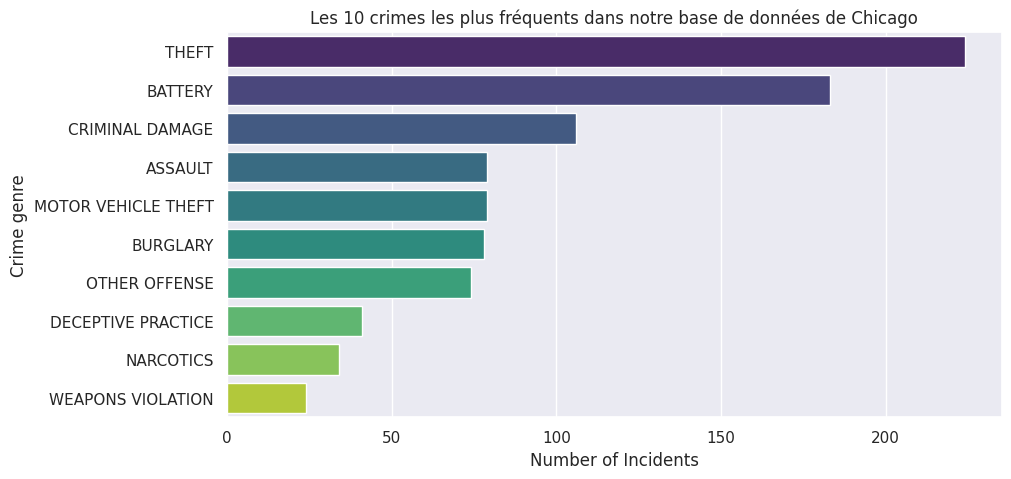

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Définissez le style et la taille du graphique
plt.figure(figsize=(10, 5))
sns.set_theme(style="darkgrid")

#  la liste des 10 types de crimes les plus fréqquents.
sns.countplot(
    y='primary_type',
    data=df,
    order=df['primary_type'].value_counts().index[:10],
    palette='viridis'
)

plt.title('Les 10 crimes les plus fréquents dans notre base de données de Chicago')
plt.xlabel('Number of Incidents')
plt.ylabel('Crime genre')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Sélection des variables (features) utiles pour la prédiction
# Nous utilisons le type de crime, si c'est un acte domestique, et le district de police
features = ['primary_type', 'domestic', 'district']
X = df[features].copy()
y = df['arrest'].copy()

# 2. Gestion des valeurs manquantes (remplissage par la valeur la plus fréquente)
X = X.fillna(X.mode().iloc[0])

# 3. Encodage des données textuelles (convertir le texte en nombres pour le modèle)
encoder_crime = LabelEncoder()
X['primary_type'] = encoder_crime.fit_transform(X['primary_type'])

encoder_domestic = LabelEncoder()
X['domestic'] = encoder_domestic.fit_transform(X['domestic'])

# Convertir la variable cible 'arrest' (True/False) en nombres (1 et 0)
encoder_target = LabelEncoder()
y = encoder_target.fit_transform(y)

# 4. Division des données : 80% pour l'entraînement des modèles, 20% pour le test final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Prétraitement terminé avec succès ! ---")
print(f"Nombre de lignes pour l'entraînement des modèles : {X_train.shape[0]}")
print(f"Nombre de lignes réservées pour la validation/test : {X_test.shape[0]}")

--- Prétraitement terminé avec succès ! ---
Nombre de lignes pour l'entraînement des modèles : 800
Nombre de lignes réservées pour la validation/test : 200


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialisation des modèles de classification (Correction du bug max_iter)
modele_logreg = LogisticRegression(max_iter=1000, random_state=42)
modele_tree = DecisionTreeClassifier(random_state=42)

# 2. Entraînement des modèles avec les données d'apprentissage (X_train, y_train)
print("--- Entraînement des modèles en cours... ---")
modele_logreg.fit(X_train, y_train)
modele_tree.fit(X_train, y_train)
print("Entraînement terminé avec succès !\n")

# 3. Prédictions sur les données de test (X_test)
predictions_logreg = modele_logreg.predict(X_test)
predictions_tree = modele_tree.predict(X_test)

# 4. Évaluation et affichage des scores de précision (Accuracy)
score_logreg = accuracy_score(y_test, predictions_logreg)
score_tree = accuracy_score(y_test, predictions_tree)

print("==================================================")
print("             RÉSULTATS DES MODÈLES                ")
print("==================================================")
print(f"Précision (Accuracy) de la Régression Logistique : {score_logreg * 100:.2f}%")
print(f"Précision (Accuracy) de l'Arbre de Décision       : {score_tree * 100:.2f}%")
print("==================================================\n")

# 5. Rapport de classification détaillé pour chaque technique
print("--- Rapport détaillé : Régression Logistique ---")
print(classification_report(y_test, predictions_logreg, target_names=['Pas d\'arrêt', 'Arrêt']))

print("\n--- Rapport détaillé : Arbre de Décision ---")
print(classification_report(y_test, predictions_tree, target_names=['Pas d\'arrêt', 'Arrêt']))

--- Entraînement des modèles en cours... ---
Entraînement terminé avec succès !

             RÉSULTATS DES MODÈLES                
Précision (Accuracy) de la Régression Logistique : 85.50%
Précision (Accuracy) de l'Arbre de Décision       : 87.50%

--- Rapport détaillé : Régression Logistique ---
              precision    recall  f1-score   support

 Pas d'arrêt       0.85      1.00      0.92       171
       Arrêt       0.00      0.00      0.00        29

    accuracy                           0.85       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.73      0.85      0.79       200


--- Rapport détaillé : Arbre de Décision ---
              precision    recall  f1-score   support

 Pas d'arrêt       0.89      0.97      0.93       171
       Arrêt       0.64      0.31      0.42        29

    accuracy                           0.88       200
   macro avg       0.77      0.64      0.67       200
weighted avg       0.86      0.88      0.86       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
